In [1]:
import os 
os.chdir('../../')
os.environ["DPM_TQDM"] = "False"
os.environ["CUDA_VISIBLE_DEVICES"]="1"

!nvidia-smi

Fri Aug 29 02:35:29 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.76.05              Driver Version: 580.76.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5090        Off |   00000000:19:00.0 Off |                  N/A |
| 94%   81C    P1            346W /  400W |    8633MiB /  32607MiB |     91%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from backbones.dit import DiT

# 사용 예
model = DiT()
print(model)

/home/scpark/miniconda3/envs/dual/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading pipeline components...:   0%|          | 0/3 [00:00<?, ?it/s]An error occurred while trying to fetch /home/scpark/.cache/huggingface/hub/models--facebook--DiT-XL-2-256/snapshots/eab87f77abd5aef071a632f08807fbaab0b704d0/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /home/scpark/.cache/huggingface/hub/models--facebook--DiT-XL-2-256/snapshots/eab87f77abd5aef071a632f08807fbaab0b704d0/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
Loading pipeline components...:  67%|██████▋   | 2/3 [00:00<00:00, 19.41it/s]An error occurred while trying to fetch /home/scpark/.cache/huggingface/hub/models--facebook--DiT-XL-2-256/snapshots/eab87f77abd5aef071a

In [3]:
import numpy as np
# 클래스 0–9로 설정
class_start = np.random.randint(0, 900)
#class_start = 10
class_ids = [i for i in range(class_start, class_start+100, 10)]
noise_schedule = model.get_noise_schedule()
model_fn = model.get_model_fn(noise_schedule=noise_schedule, pos_conds=class_ids, guidance_scale=3.0)
noises = model.get_noise(seeds=class_ids)


In [4]:
from solvers.common import NoiseScheduleVP, model_wrapper
schedule = NoiseScheduleVP(schedule="discrete", betas=model.pipe.scheduler.betas, dtype=model.dtype)

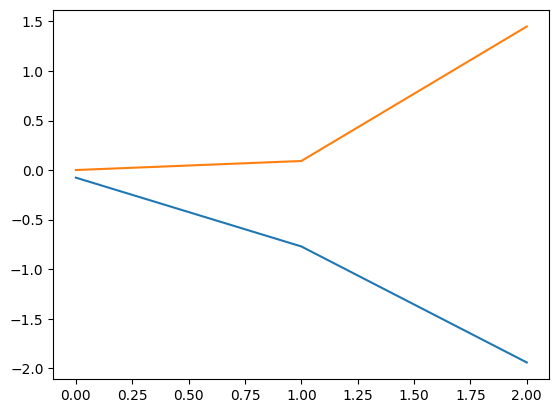

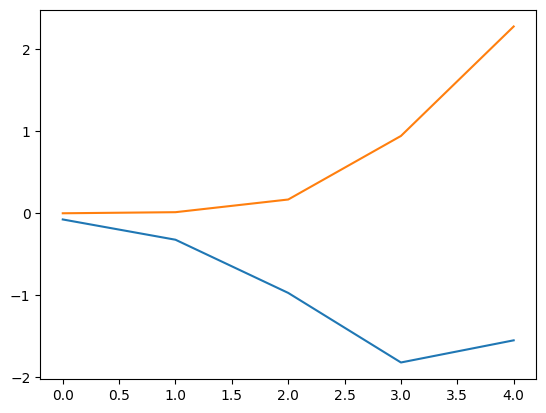

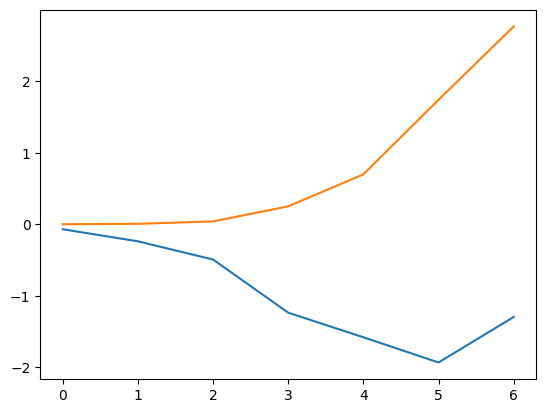

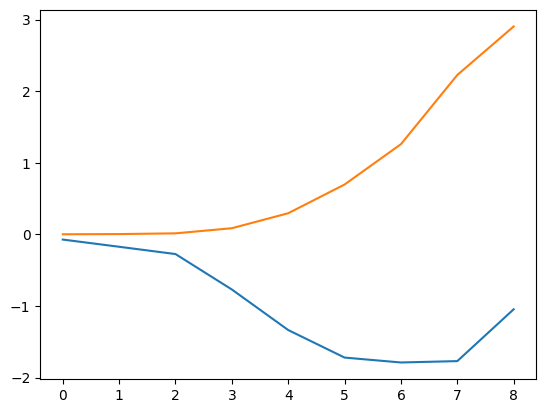

In [5]:
from solvers.competing.ds.ds_solver_ddpm import DS_Solver
for steps in [3, 5, 7, 9]:
    solver = DS_Solver(
            noise_schedule,
            steps=steps,
            skip_type="time_uniform",
        ).to(model.device)

    import matplotlib.pyplot as plt
    plt.plot(schedule.dalpha(solver.learned_timesteps(), dt=0.1/steps).cpu().detach().numpy())
    plt.plot(schedule.dsigma(solver.learned_timesteps(), dt=0.1/steps).cpu().detach().numpy())
    plt.show()

In [6]:
solver.learned_timesteps().shape

torch.Size([10])